In [ ]:
!git clone https://github.com/rasbt/reasoning-from-scratch.git
%cd reasoning-from-scratch
!pip install -r requirements.txt
!pip install sympy antlr4-python3-runtime==4.11.1

fatal: destination path 'reasoning-from-scratch' already exists and is not an empty directory.
/content/reasoning-from-scratch
  Using cached antlr4_python3_runtime-4.11.1-py3-none-any.whl.metadata (291 bytes)
Using cached antlr4_python3_runtime-4.11.1-py3-none-any.whl (144 kB)
  Attempting uninstall: antlr4-python3-runtime
    Found existing installation: antlr4-python3-runtime 4.9.3
    Uninstalling antlr4-python3-runtime-4.9.3:
      Successfully uninstalled antlr4-python3-runtime-4.9.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
omegaconf 2.3.0 requires antlr4-python3-runtime==4.9.*, but you have antlr4-python3-runtime 4.11.1 which is incompatible.


# Inference Time Scaling Evaluation

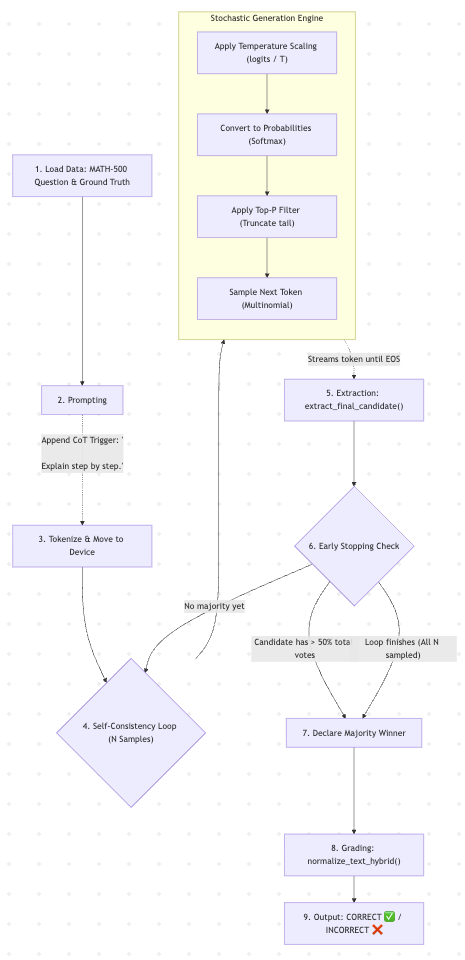

## What this script does
Extends the Chapter 3 evaluator with **three inference-time scaling techniques**
stacked on top of each other: Chain-of-Thought prompting, stochastic sampling,
and self-consistency majority voting. Same Qwen3 0.6B model, better accuracy
through smarter generation — not bigger weights.

---

## 1. Temperature Scaling (`scale_logits_by_temperature`)
Divides raw logits by a scalar before softmax.

| Temperature | Effect |
|---|---|
| `< 1.0` | Sharpens distribution → more confident, more repetitive |
| `> 1.0` | Flattens distribution → more random, more creative |
| `= 1.0` | No change |

---

## 2. Nucleus Sampling (`top_p_filter`)
Zeroes out the **long tail** of low-probability tokens so only the top nucleus
of tokens (whose cumulative probability reaches `top_p`) can be sampled.

**Steps:** sort descending → cumulative sum → mask tokens past the cutoff →
scatter back to vocab positions → renormalise to sum to 1.

> `top_p=0.9` means: keep the smallest set of tokens that together account
> for 90% of the probability mass. Everything else is set to zero.

---

## 3. Stochastic Generation Loop (`generate_text_top_p_stream_cache`)
The Chapter 2 greedy loop, extended. Per token:
```
logits → ÷ temperature → softmax → top-p filter → multinomial sample
```
Setting `temperature=0` falls back to greedy `argmax` for deterministic runs.
KV-Cache is unchanged from Chapter 2 — still only the new token is processed
each step.

---

## 4. Self-Consistency / Majority Voting (`self_consistency_vote`)
**Core idea (Wang et al. 2022):** generate N independent CoT responses via
stochastic sampling, extract the final answer from each, return the most
frequent one.

Why it works: different reasoning paths tend to converge on the same *correct*
answer, while errors tend to be random and spread across many wrong answers.

**Early stopping:** if one candidate already has a strict majority (> N/2 votes)
before all N samples are done, stop early and return it — saves compute.

---

## 5. Evaluation Loop (`run_ch4_evaluation`)

```
For each problem:
  1. BUILD   — render_prompt() + "\n\nExplain step by step." (CoT trigger)
  2. VOTE    — self_consistency_vote() runs NUM_SAMPLES stochastic generations
  3. GRADE   — normalize_text_hybrid() on both voted answer and ground truth → string compare
```

**Key hyperparameters:**

| Parameter | Value | Why |
|---|---|---|
| `TEMPERATURE` | 0.8 | Enough diversity between samples without becoming incoherent |
| `TOP_P` | 0.9 | Filters the long tail while keeping a wide enough nucleus |
| `NUM_SAMPLES` | 5 | Majority voting pool size |
| `max_new_tokens` | 512 | More room for step-by-step working (vs 256 in Ch3) |

In [2]:
import torch
from collections import Counter
import json
import re
import requests
from pathlib import Path

# ── Chapter 2 utilities: hardware detection (reused from previous chapters)
from reasoning_from_scratch.ch02 import get_device

# ── Qwen3 model components
from reasoning_from_scratch.qwen3 import (
    download_qwen3_small,
    Qwen3Model,
    Qwen3Tokenizer,
    QWEN_CONFIG_06_B,
    KVCache
)

# ── Chapter 3 utilities: dataset loader, prompt formatter, answer extractor
from reasoning_from_scratch.ch03 import (
    load_math500_test,        # Downloads/caches the MATH-500 benchmark JSON
    render_prompt,            # Wraps a problem in the \boxed{} instruction prompt
    extract_final_candidate   # Pulls the answer out of \boxed{} or falls back to last number
)

# ── Heavy LaTeX normaliser (requires antlr4-python3-runtime==4.11.3)
from reasoning_from_scratch.bonus.parser import normalize_text_hybrid


# ─────────────────────────────────────────────
# 1. TEMPERATURE SCALING
# ─────────────────────────────────────────────

def scale_logits_by_temperature(logits, temperature):
    """
    Divides raw logits by a temperature value before softmax is applied.

    Effect on the resulting probability distribution:
      temperature < 1.0 → distribution sharpens (model becomes more confident / repetitive)
      temperature > 1.0 → distribution flattens (model becomes more random / creative)
      temperature = 1.0 → no change (standard softmax behaviour)

    Raises ValueError for temperature <= 0 because that is mathematically undefined.
    """
    if temperature <= 0:
        raise ValueError("Temperature must be positive")
    return logits / temperature


# ─────────────────────────────────────────────
# 2. NUCLEUS (TOP-P) FILTERING
# ─────────────────────────────────────────────

def top_p_filter(probas, top_p):
    """
    Nucleus Sampling filter: zeroes out low-probability tokens so that only
    the smallest set of tokens whose cumulative probability reaches `top_p`
    are eligible for sampling.

    Example with top_p=0.9:
      Sorted probas: [0.5, 0.3, 0.15, 0.04, 0.01, ...]
      Cumulative:    [0.5, 0.8,  0.95, ...]
      Keep up to the token that pushes cumsum past 0.9 → keep first 3 tokens.
      Everything after is zeroed out (the "long tail" of unlikely tokens).

    This prevents the model from ever sampling nonsensical low-probability tokens
    while still allowing creative variation within the high-probability nucleus.

    Steps:
      1. Sort probabilities descending and track original vocab indices.
      2. Compute cumulative sum; find the cutoff where it first exceeds top_p.
         (We subtract sorted_probas before comparing so the token that *crosses*
          the threshold is included, not excluded.)
      3. Zero out everything outside the nucleus.
      4. Scatter values back to their original vocabulary positions.
      5. Renormalise so the kept probabilities sum to 1.0.
    """
    if top_p is None or top_p >= 1.0:
        return probas  # No filtering — use the full vocabulary

    # Sort tokens from most to least probable; keep track of original indices
    sorted_probas, sorted_idx = torch.sort(probas, dim=1, descending=True)
    cumprobas = torch.cumsum(sorted_probas, dim=1)

    # `prefix` is the cumulative sum BEFORE adding the current token.
    # A token is kept if the prefix alone hasn't yet reached top_p —
    # meaning this token is still needed to get there.
    prefix = cumprobas - sorted_probas
    keep = prefix < top_p
    keep[:, 0] = True  # Always keep the single most likely token as a safety guard

    # Zero out tokens outside the nucleus (replace with 0, keep the rest)
    kept_sorted = torch.where(keep, sorted_probas, torch.zeros_like(sorted_probas))

    # Scatter filtered values back to their original vocabulary positions
    filtered = torch.zeros_like(probas).scatter(1, sorted_idx, kept_sorted)

    # Renormalise: clamp_min(1e-12) prevents division by zero if all tokens were zeroed
    return filtered / torch.sum(filtered, dim=1).clamp_min(1e-12)


# ─────────────────────────────────────────────
# 3. STOCHASTIC GENERATION LOOP
# ─────────────────────────────────────────────

@torch.inference_mode()
def generate_text_top_p_stream_cache(
    model, token_ids, max_new_tokens,
    eos_token_id=None, temperature=1.0, top_p=0.9
):
    """
    The Chapter 2 streaming generator extended with stochastic sampling.

    At each step, instead of always picking the single highest-logit token
    (greedy / argmax), this version:
      1. Scales logits by temperature.
      2. Converts to probabilities via softmax.
      3. Applies the top-p nucleus filter.
      4. Samples from the filtered distribution with torch.multinomial.

    Setting temperature=0 or temperature=None falls back to greedy decoding,
    which is useful for deterministic baselines or ablation comparisons.

    The KV-Cache (same as Chapter 2) means only the single new token is
    processed per step — all previous context is served from the cache.
    """
    model.eval()
    cache = KVCache(n_layers=model.cfg["n_layers"])
    model.reset_kv_cache()

    # Prefill: process the full prompt once to populate the KV-Cache
    out = model(token_ids, cache=cache)[:, -1]

    for _ in range(max_new_tokens):
        orig_device = token_ids.device

        if temperature is None or temperature == 0.0:
            # Greedy decoding — deterministic, always picks the top token
            next_token = torch.argmax(out, dim=-1, keepdim=True)
        else:
            # Stochastic sampling pipeline
            logits = scale_logits_by_temperature(out, temperature)  # Step 1: scale
            probas = torch.softmax(logits, dim=-1)                  # Step 2: to probs
            probas = top_p_filter(probas, top_p)                    # Step 3: nucleus filter
            # Step 4: sample — multinomial runs on CPU, then move back to original device
            next_token = torch.multinomial(probas.cpu(), num_samples=1).to(orig_device)

        if eos_token_id is not None and torch.all(next_token == eos_token_id):
            break

        yield next_token  # Stream each token as it is produced

        # Feed only the new token into the model; cache supplies the rest
        out = model(next_token, cache=cache)[:, -1]


def generate_text_concat_flex(model, tokenizer, prompt, device, max_new_tokens, temperature, top_p):
    """
    Thin wrapper around the streaming generator that collects all yielded tokens
    and returns a single decoded string.

    Used by self_consistency_vote to get a complete response per sample.
    """
    input_ids = torch.tensor(tokenizer.encode(prompt), device=device).unsqueeze(0)
    generated_ids = []
    for token in generate_text_top_p_stream_cache(
        model, input_ids, max_new_tokens, tokenizer.eos_token_id, temperature, top_p
    ):
        generated_ids.append(token.squeeze(0).item())
    return tokenizer.decode(generated_ids)


# ─────────────────────────────────────────────
# 4. SELF-CONSISTENCY (MAJORITY VOTING)
# ─────────────────────────────────────────────

def self_consistency_vote(
    model, tokenizer, prompt, device,
    num_samples=5, temperature=0.8, top_p=0.9,
    max_new_tokens=256, early_stop=True
):
    """
    Inference-time scaling via Self-Consistency (Wang et al., 2022).

    Core idea: generate N independent Chain-of-Thought responses to the same
    question using stochastic sampling (so each response is different), extract
    the final answer from each, then take a majority vote. Empirically, correct
    reasoning paths tend to converge on the same answer even when the
    intermediate steps differ.

    Args:
        num_samples  : Pool size N — how many independent responses to generate.
        temperature  : Controls diversity between samples. Too low → all samples
                       identical (defeats the purpose). Too high → incoherent.
                       0.8 is a common sweet spot.
        top_p        : Nucleus filter applied within each sample.
        early_stop   : If one candidate already has a strict majority (>50%),
                       stop generating remaining samples early to save compute.

    Returns:
        The most frequently occurring answer string across all samples.
    """
    counts = Counter()

    for i in range(num_samples):
        # Generate one full Chain-of-Thought response with stochastic sampling
        answer = generate_text_concat_flex(
            model, tokenizer, prompt, device, max_new_tokens, temperature, top_p
        )

        # Extract just the short answer candidate (from \boxed{} or last number)
        short = extract_final_candidate(answer)
        counts[short] += 1
        print(f"   [Sample {i+1}/{num_samples}] Generated candidate: {short!r}")

        # Early stopping: if one candidate already holds a strict majority,
        # additional samples can't change the outcome — skip them to save time
        if early_stop and counts[short] > num_samples / 2:
            print(f"   -> Early stop! Strict majority reached for {short!r}")
            return short

    # No early stop triggered — return whichever answer appeared most often
    return counts.most_common(1)[0][0]


# ─────────────────────────────────────────────
# 5. EVALUATION ENGINE
# ─────────────────────────────────────────────

def run_ch4_evaluation(dataset_size=3):
    """
    End-to-end Chapter 4 evaluation loop combining:
      - Chain-of-Thought prompting (step-by-step suffix)
      - Stochastic sampling (temperature + top-p)
      - Self-consistency majority voting (N samples per question)
      - Hybrid LaTeX normalisation for robust grading

    Hyperparameters are defined in one place at the top of the loop
    so they're easy to tune.
    """

    # ── Parser health-check (same guard as Chapter 3) ─────────────────────
    # Must pass before loading the model — no point running inference if
    # the grader is silently broken.
    if normalize_text_hybrid(r"\frac{1}{2}") != "1/2":
        raise RuntimeError(
            "🚨 Hybrid LaTeX parser failed to load! "
            "Run `!pip install antlr4-python3-runtime==4.11.1` and RESTART your session."
        )

    # ── Model setup ───────────────────────────────────────────────────────
    device = get_device()
    print(f"Using device: {device}")

    download_qwen3_small(kind="base", tokenizer_only=False, out_dir="qwen3")
    tokenizer = Qwen3Tokenizer(tokenizer_file_path="qwen3/tokenizer-base.json")

    model = Qwen3Model(QWEN_CONFIG_06_B)
    model.load_state_dict(
        torch.load("qwen3/qwen3-0.6B-base.pth", map_location=device, weights_only=True)
    )
    model.to(device).eval()

    # ── Dataset ───────────────────────────────────────────────────────────
    math_data = load_math500_test()[:dataset_size]

    # ── Inference scaling hyperparameters ─────────────────────────────────
    PROMPT_SUFFIX  = "\n\nExplain step by step."  # Triggers Chain-of-Thought reasoning
    TEMPERATURE    = 0.8   # Diversity between samples — high enough to vary, low enough to stay coherent
    TOP_P          = 0.9   # Nucleus size — top 90% of probability mass is eligible for sampling
    NUM_SAMPLES    = 5     # How many independent CoT responses to majority-vote over

    print("\nStarting Chapter 4 Inference Scaling...")
    num_correct = 0

    for i, row in enumerate(math_data, 1):

        # Step 1: Build the Chain-of-Thought prompt
        # render_prompt() adds the \boxed{} instruction; the suffix adds "Explain step by step."
        cot_prompt = render_prompt(row["problem"]) + PROMPT_SUFFIX

        print(f"\n--- Question {i} ---")

        # Step 2: Run self-consistency — generate NUM_SAMPLES responses and majority vote
        # max_new_tokens=512 gives the model more room for step-by-step working
        majority_answer = self_consistency_vote(
            model, tokenizer, cot_prompt, device,
            num_samples=NUM_SAMPLES,
            temperature=TEMPERATURE,
            top_p=TOP_P,
            max_new_tokens=512
        )

        # Step 3: Normalise both the voted answer and the ground truth with the
        # hybrid parser so LaTeX variants all collapse to the same canonical form
        pred = normalize_text_hybrid(majority_answer)
        gold = normalize_text_hybrid(row["answer"])
        is_correct = (pred == gold)
        num_correct += int(is_correct)

        print(f"Expected : {row['answer']}")
        print(f"Voted    : {majority_answer}")
        print(f"Graded   : {'CORRECT ✅' if is_correct else 'INCORRECT ❌'}")

    print(f"\nFinal Accuracy: {num_correct}/{dataset_size}")


# ── Entry point ────────────────────────────────────────────────────────────────
run_ch4_evaluation(dataset_size=50)

Using NVIDIA CUDA GPU
Using device: cuda
qwen3-0.6B-base.pth: 100% (1433 MiB / 1433 MiB)

Starting Chapter 4 Inference Scaling...

--- Question 1 ---
   [Sample 1/5] Generated candidate: '2'
   [Sample 2/5] Generated candidate: '(3, \\frac{\\pi}{2})'
   [Sample 3/5] Generated candidate: '\\left(3, \\frac{\\pi}{2}\\right)'
   [Sample 4/5] Generated candidate: '2'
   [Sample 5/5] Generated candidate: '\\left(3, \\frac{\\pi}{2}\\right)'
Expected : \left( 3, \frac{\pi}{2} \right)
Voted    : 2
Graded   : INCORRECT ❌

--- Question 2 ---
   [Sample 1/5] Generated candidate: '1'
   [Sample 2/5] Generated candidate: '5'
   [Sample 3/5] Generated candidate: '3'
   [Sample 4/5] Generated candidate: '2'
   [Sample 5/5] Generated candidate: '1'
Expected : p - q
Voted    : 1
Graded   : INCORRECT ❌

--- Question 3 ---
   [Sample 1/5] Generated candidate: '\\frac{14}{3}'
   [Sample 2/5] Generated candidate: '\\frac{14}{3}'
   [Sample 3/5] Generated candidate: '\\frac{14}{3}'
   -> Early stop! Strict m